In [1]:
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa.display
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
def create_melspectrogram(segmented_dir, n_mels=128):
    segmented_dir = Path(segmented_dir)
    X = []
    y = []
    labels = [f.name for f in segmented_dir.iterdir() if f.is_dir()]

    for label in tqdm(labels):
        for audio in (segmented_dir / label).iterdir():
            if audio.suffix == ".wav":
                signal, sr = librosa.load(audio, sr=None)
                melspectrogram = librosa.feature.melspectrogram(y=signal, 
                                                                sr=sr, 
                                                                n_mels=n_mels, 
                                                                fmax=sr/2)
                melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
                X.append(melspectrogram_db)
                y.append(label)
            
    X = np.array(X)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    return X, np.array(y), label_encoder

Import data for model

In [3]:
X, y, label_encoder = create_melspectrogram('IRMAS_segmented')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

100%|██████████| 11/11 [09:36<00:00, 52.38s/it] 


Plot mel spectrogram

In [4]:
def plot_melspectrogram(X, i=0, save_path=None):
    melspectrogram_sample = X[i, :, :, 0]
    librosa.display.specshow(melspectrogram_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

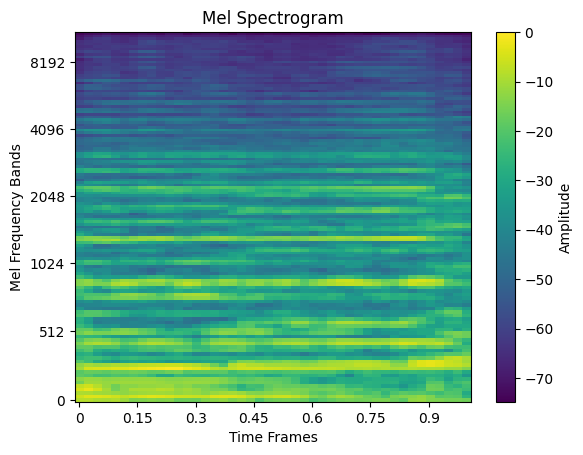

In [5]:
plot_melspectrogram(X)

CNN model

In [6]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

cnn = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2], 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'])

Train CNN

In [ ]:
early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = cnn.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)

with open("IRMAS_cnn_melspectrogram_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.2283 - loss: 2.2199
Epoch 1: val_accuracy improved from -inf to 0.11774, saving model to IRMAS_cnn_melspectrogram.weights.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 60s 115ms/step - accuracy: 0.2285 - loss: 2.2196 - val_accuracy: 0.1177 - val_loss: 2.7930
Epoch 2/100
402/403 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3692 - loss: 1.8746
Epoch 2: val_accuracy improved from 0.11774 to 0.25722, saving model to IRMAS_cnn_melspectrogram.weights.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 80s 110ms/step - accuracy: 0.3693 - loss: 1.8743 - val_accuracy: 0.2572 - val_loss: 2.2026
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4555 - loss: 1.6458
Epoch 3: val_accuracy improved from 0.25722 to 0.28456, saving model to IRMAS_cnn_melspectrogram.weights.h5
403/403 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - accuracy: 0.4555 - loss: 1.6457 - val_accuracy: 0.2846 - val_loss: 2.4241
Epoch 4/100
402/403 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/ste

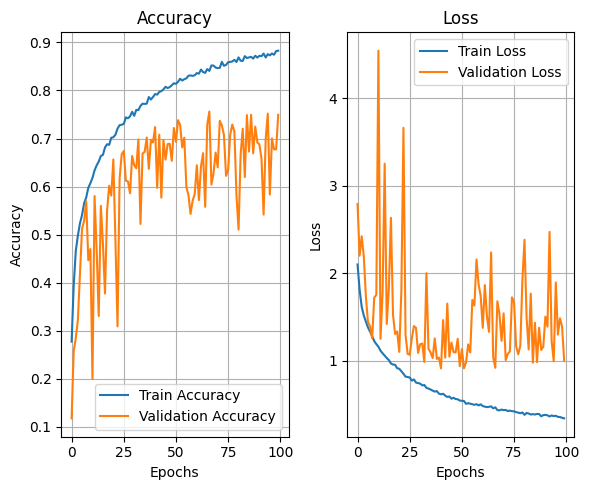

In [ ]:
with open("IRMAS_cnn_melspectrogram_history.pkl", "rb") as f:
    history = pickle.load(f)
    
plt.figure(figsize=(6, 5))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("IRMAS_cnn_melspectrogram_training_curves.png")
plt.show()

Evaluate CNN

In [9]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

output_file = 'IRMAS_cnn_melspectrogram_evaluation.txt'

with open(output_file, 'w') as file:
    file.write(f'Accuracy: {accuracy}\n')
    file.write('\nClassification Report:\n')
    file.write(class_report)

# best .71

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy: 0.744220730797912

Classification Report:
               precision    recall  f1-score   support

         cel       0.53      0.86      0.65       233
         cla       0.75      0.69      0.72       303
         flu       0.74      0.64      0.68       270
         gac       0.83      0.68      0.75       382
         gel       0.67      0.68      0.67       456
         org       0.92      0.84      0.88       409
         pia       0.77      0.85      0.81       433
         sax       0.74      0.57      0.64       376
         tru       0.79      0.84      0.81       346
         vio       0.60      0.68      0.63       348
         voi       0.87      0.82      0.84       467

    accuracy                           0.74      4023
   macro avg       0.75      0.74      0.74      4023
weighted avg       0.76      0.74      0.75      4023



Save CNN

In [10]:
# cnn.save('cnn_melspectrogram_model.h5')